In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shutil, os
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from PIL import Image
from sklearn.model_selection import train_test_split
import torchvision.transforms.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.distributions import Normal
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve

In [174]:
df = pd.read_csv("/kaggle/input/chexchonet/chexchonet-a-chest-radiograph-dataset-with-gold-standard-echocardiography-labels-1.0.0/metadata.csv")

print("Healthy:", len(df[(df.slvh==0)&(df.dlv==0)]))
print("SLVH:", len(df[(df.slvh==1)&(df.dlv==0)]))
print("DLV:", len(df[(df.slvh==0)&(df.dlv==1)]))
print("Both:", len(df[(df.slvh==1)&(df.dlv==1)]))

Healthy: 61728
SLVH: 5518
DLV: 3670
Both: 673


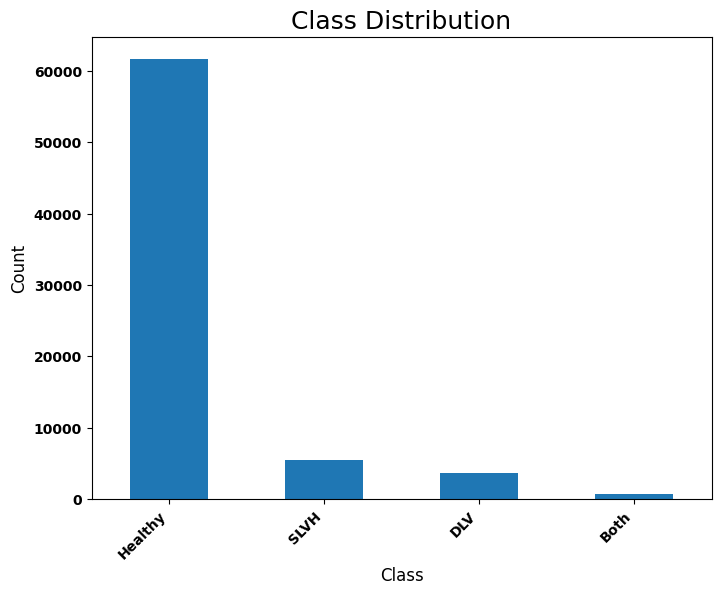

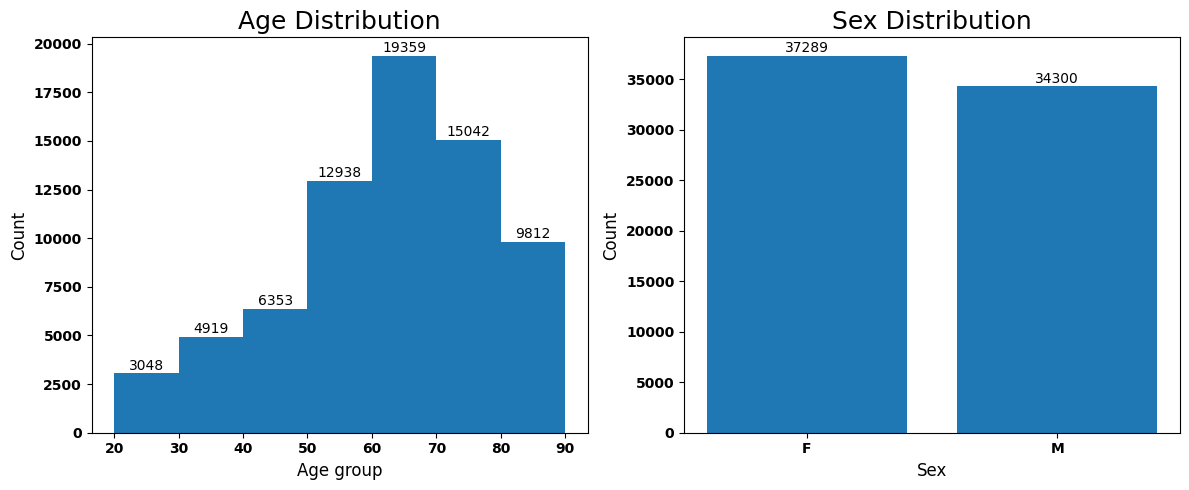

In [176]:
df = pd.read_csv("/kaggle/input/chexchonet/chexchonet-a-chest-radiograph-dataset-with-gold-standard-echocardiography-labels-1.0.0/metadata.csv")

conditions = np.select(
    [
        (df.slvh==0)&(df.dlv==0),
        (df.slvh==1)&(df.dlv==0),
        (df.slvh==0)&(df.dlv==1),
        (df.slvh==1)&(df.dlv==1)
    ],
    ["Healthy","SLVH","DLV","Both"],
    default="Unknown"
)
df["class_group"] = conditions

plt.figure(figsize=(8,6))
counts = df["class_group"].value_counts()
bars = counts.plot(kind="bar")
plt.title("Class Distribution", fontsize=18)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ages = df["age"].dropna()
bins = list(range(20, 100, 10))

n, bins_edges, patches = axes[0].hist(ages, bins=bins)
axes[0].set_title("Age Distribution", fontsize=18)
axes[0].set_xlabel("Age group", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

axes[0].tick_params(axis='both', labelcolor='black')
for tick in axes[0].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[0].get_yticklabels():
    tick.set_fontweight('bold')

for i in range(len(n)):
    x = (bins_edges[i] + bins_edges[i+1]) / 2
    axes[0].text(x, n[i] + max(n)*0.01, str(int(n[i])), ha='center')

sex_counts = df["sex"].value_counts()

axes[1].bar(sex_counts.index, sex_counts.values)
axes[1].set_title("Sex Distribution", fontsize=18)
axes[1].set_xlabel("Sex", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

axes[1].tick_params(axis='both', labelcolor='black')
for tick in axes[1].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[1].get_yticklabels():
    tick.set_fontweight('bold')

for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + max(sex_counts.values)*0.01, str(v), ha='center')

plt.tight_layout()
plt.show()

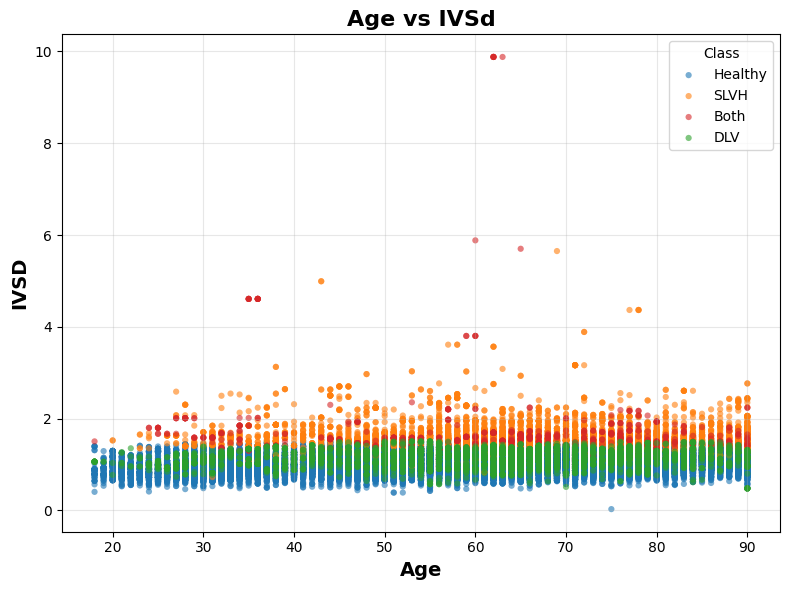

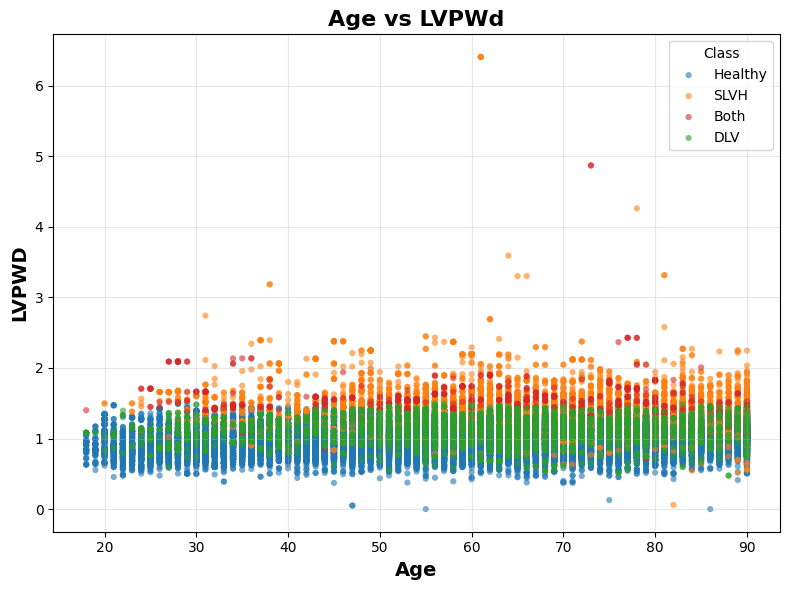

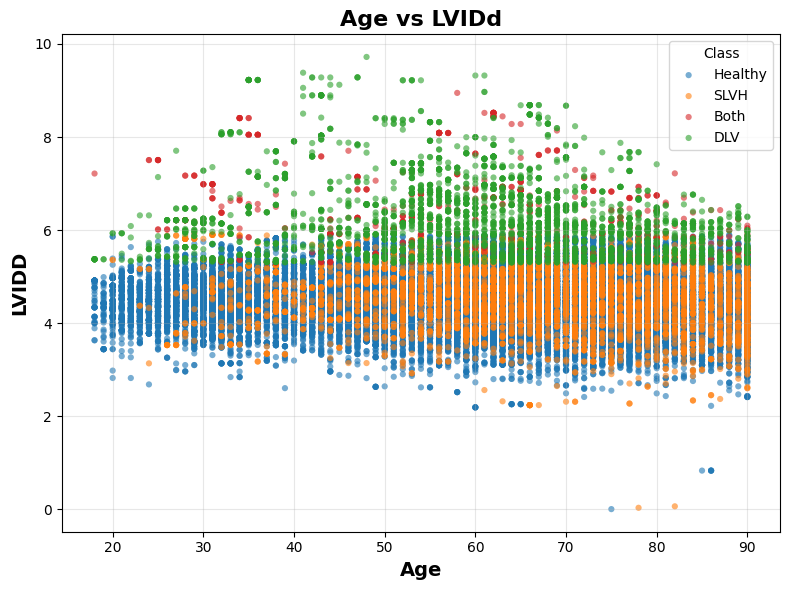

In [177]:
colors = {
    "Healthy": "tab:blue",
    "SLVH": "tab:orange",
    "DLV": "tab:green",
    "Both": "tab:red"
}

def scatter_age_metric(df, metric, title):
    plt.figure(figsize=(8,6))
    
    for cls in df["class_group"].unique():
        subset = df[df["class_group"] == cls]
        plt.scatter(
            subset["age"], subset[metric],
            label=cls,
            alpha=0.6,
            s=20,
            edgecolors="none",
            color=colors.get(cls, "gray")
        )
    
    plt.xlabel("Age", fontsize=14, fontweight="bold")
    plt.ylabel(metric.upper(), fontsize=14, fontweight="bold")
    plt.title(title, fontsize=16, fontweight="bold")
    plt.legend(title="Class", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

scatter_age_metric(df, "ivsd", "Age vs IVSd")
scatter_age_metric(df, "lvpwd", "Age vs LVPWd")
scatter_age_metric(df, "lvidd", "Age vs LVIDd")

In [142]:
subset_path = "/kaggle/working/subset_dataset"

if os.path.exists(subset_path):
    shutil.rmtree(subset_path)

os.makedirs(subset_path, exist_ok=True)
os.makedirs(os.path.join(subset_path, "images"), exist_ok=True)

df = pd.read_csv('/kaggle/input/chexchonet/chexchonet-a-chest-radiograph-dataset-with-gold-standard-echocardiography-labels-1.0.0/metadata.csv')

healthy      = df[(df.slvh == 0) & (df.dlv == 0)].sample(5000, random_state=42)
slvh_only    = df[(df.slvh == 1) & (df.dlv == 0)].sample(2100, random_state=42)
dlv_only     = df[(df.slvh == 0) & (df.dlv == 1)].sample(2100, random_state=42)
both_diseases = df[(df.slvh == 1) & (df.dlv == 1)].sample(673, random_state=42)

df_subset = pd.concat([healthy, slvh_only, dlv_only, both_diseases])

src_img_dir = "/kaggle/input/chexchonet/chexchonet-a-chest-radiograph-dataset-with-gold-standard-echocardiography-labels-1.0.0/images/"
dst_img_dir = os.path.join(subset_path, "images")

for _, row in df_subset.iterrows():
    src = os.path.join(src_img_dir, row["cxr_filename"])
    dst = os.path.join(dst_img_dir, row["cxr_filename"])
    shutil.copy(src, dst)

df_subset.to_csv(os.path.join(subset_path, "metadata_subset.csv"), index=False)

print("Subset creat cu:", len(df_subset), "imagini")
print("Imaginile sunt in:", subset_path)

Subset creat cu: 9873 imagini
Imaginile sunt in: /kaggle/working/subset_dataset


In [144]:
conditions = np.select(
    [
        (df_subset.slvh==0)&(df_subset.dlv==0),
        (df_subset.slvh==1)&(df_subset.dlv==0),
        (df_subset.slvh==0)&(df_subset.dlv==1),
        (df_subset.slvh==1)&(df_subset.dlv==1)
    ],
    ["Healthy","SLVH","DLV","Both"],
    default="Unknown"
)
df_subset["class_group"] = conditions
train_df, temp_df = train_test_split(
    df_subset,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=df_subset["class_group"]
)

conditions = np.select(
    [
        (temp_df.slvh==0)&(temp_df.dlv==0),
        (temp_df.slvh==1)&(temp_df.dlv==0),
        (temp_df.slvh==0)&(temp_df.dlv==1),
        (temp_df.slvh==1)&(temp_df.dlv==1)
    ],
    ["Healthy","SLVH","DLV","Both"],
    default="Unknown"
)
temp_df["class_group"] = conditions

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=temp_df["class_group"]
)

print("Train:", len(train_df))
print(train_df["class_group"].value_counts())
print("\nVal:", len(val_df))
print(val_df["class_group"].value_counts())
print("\nTest:", len(test_df))
print(test_df["class_group"].value_counts())

Train: 8885
class_group
Healthy    4499
DLV        1890
SLVH       1890
Both        606
Name: count, dtype: int64

Val: 494
class_group
Healthy    251
DLV        105
SLVH       105
Both        33
Name: count, dtype: int64

Test: 494
class_group
Healthy    250
SLVH       105
DLV        105
Both        34
Name: count, dtype: int64


In [145]:
pixel_sum = torch.zeros(3)
pixel_sq_sum = torch.zeros(3)
total_pixels = 0

for _, row in train_df.iterrows():
    img = Image.open("/kaggle/working/subset_dataset/images/" + row["cxr_filename"]).convert("RGB")
    img_tensor = F.to_tensor(img)

    pixel_sum += img_tensor.sum(dim=[1,2])
    pixel_sq_sum += (img_tensor**2).sum(dim=[1,2])
    total_pixels += img_tensor.shape[1] * img_tensor.shape[2]

mean = pixel_sum / total_pixels
std = torch.sqrt(pixel_sq_sum / total_pixels - mean**2)

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4881, 0.4881, 0.4881])
Std: tensor([0.2551, 0.2551, 0.2551])


In [146]:
class AddGaussianNoise:
    def __init__(self, std=0.05):
        self.std = std
    def __call__(self, x):
        return x + torch.randn_like(x)*self.std

train_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
    AddGaussianNoise(0.05)
])

val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std)
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std)
])

In [147]:
IVSD_THRESH  = 1.5
LVPWD_THRESH = 1.5
LVIDD_THRESH = 5.9

age_mean = train_df["age"].mean()
age_std  = train_df["age"].std()
print("Age mean/std:", age_mean, age_std)

Age mean/std: 62.508610016882386 15.935281760536196


In [148]:
class ChexGaussianDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, age_mean=0.0, age_std=1.0):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.age_mean = age_mean
        self.age_std = age_std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.img_dir, row["cxr_filename"])
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        age = (float(row["age"]) - self.age_mean) / self.age_std
        age = torch.tensor(age, dtype=torch.float32)

        sex_str = str(row["sex"]).strip().upper()
        if sex_str == "F":
            sex_oh = torch.tensor([1.0, 0.0], dtype=torch.float32)
        elif sex_str == "M":
            sex_oh = torch.tensor([0.0, 1.0], dtype=torch.float32)
        else:
            sex_oh = torch.tensor([0.0, 0.0], dtype=torch.float32)

        reg_target = torch.tensor([
            float(row["ivsd"]),
            float(row["lvpwd"]),
            float(row["lvidd"])
        ], dtype=torch.float32)

        cls_target = torch.tensor([
            float(row["slvh"]),
            float(row["dlv"]),
            float(row["composite_slvh_dlv"])
        ], dtype=torch.float32)

        return img, age, sex_oh, reg_target, cls_target

In [149]:
img_path = "/kaggle/working/subset_dataset/images/"

train_dataset = ChexGaussianDataset(train_df, img_path, train_transform, age_mean, age_std)
val_dataset   = ChexGaussianDataset(val_df,   img_path, val_transform,   age_mean, age_std)
test_dataset  = ChexGaussianDataset(test_df,  img_path, test_transform,  age_mean, age_std)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [150]:
class GaussianLVModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.densenet121(weights="IMAGENET1K_V1").features
        self.gap = nn.AdaptiveAvgPool2d((1,1))

        fc_in = 1024 + 1 + 2

        self.head = nn.Sequential(
            nn.Linear(fc_in, 256),
            nn.ReLU(),
            nn.Linear(256, 6)
        )

    def forward(self, x, age, sex_oh):
        f = self.backbone(x)
        f = self.gap(f)
        f = f.view(f.size(0), -1)

        extra = torch.cat([age.unsqueeze(1), sex_oh], dim=1)
        z = torch.cat([f, extra], dim=1)

        out = self.head(z)

        mu = out[:, 0::2]
        logvar = out[:, 1::2]

        return mu, logvar

In [151]:
def gaussian_nll(mu, logvar, target):
    var = torch.exp(logvar)
    nll = 0.5 * (logvar + (target - mu)**2 / var + np.log(2*np.pi))
    return nll.mean()

In [152]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = GaussianLVModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using: cuda


In [153]:
def compute_probabilities(mu, logvar):
    sigma = torch.exp(0.5 * logvar)

    dist_ivsd  = Normal(mu[:,0], sigma[:,0])
    dist_lvpwd = Normal(mu[:,1], sigma[:,1])
    dist_lvidd = Normal(mu[:,2], sigma[:,2])

    p_ivsd  = 1.0 - dist_ivsd.cdf(torch.tensor(IVSD_THRESH,  device=mu.device))
    p_lvpwd = 1.0 - dist_lvpwd.cdf(torch.tensor(LVPWD_THRESH, device=mu.device))
    p_lvidd = 1.0 - dist_lvidd.cdf(torch.tensor(LVIDD_THRESH, device=mu.device))

    p_slvh = p_ivsd + p_lvpwd - p_ivsd * p_lvpwd
    p_dlv = p_lvidd
    p_comp = p_slvh + p_dlv - p_slvh * p_dlv

    probs = torch.stack([p_slvh, p_dlv, p_comp], dim=1)
    return probs

In [154]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n = 0

    for img, age, sex_oh, reg_target, cls_target in loader:
        img        = img.to(device)
        age        = age.to(device)
        sex_oh     = sex_oh.to(device)
        reg_target = reg_target.to(device)

        optimizer.zero_grad()
        mu, logvar = model(img, age, sex_oh)
        loss = gaussian_nll(mu, logvar, reg_target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * img.size(0)
        n += img.size(0)

    return total_loss / n

def validate(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []
    losses = []
    with torch.no_grad():
        for img, age, sex_oh, reg_target, cls_target in loader:
            img        = img.to(device)
            age        = age.to(device)
            sex_oh     = sex_oh.to(device)
            reg_target = reg_target.to(device)
            cls_target = cls_target.to(device)

            mu, logvar = model(img, age, sex_oh)

            loss = gaussian_nll(mu, logvar, reg_target)
            losses.append(loss.item())

            probs = compute_probabilities(mu, logvar).cpu().numpy()
            targs = cls_target.cpu().numpy()

            all_probs.append(probs)
            all_targets.append(targs)

    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    auc_slvh = roc_auc_score(all_targets[:,0], all_probs[:,0])
    auc_dlv  = roc_auc_score(all_targets[:,1], all_probs[:,1])
    auc_comp = roc_auc_score(all_targets[:,2], all_probs[:,2])

    return {
        "loss": np.mean(losses),
        "auc_slvh": auc_slvh,
        "auc_dlv": auc_dlv,
        "auc_comp": auc_comp
    }

def compute_auc(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for img, age, sex_oh, reg_target, cls_target in loader:
            img = img.to(device)
            age = age.to(device)
            sex_oh = sex_oh.to(device)
            cls_target = cls_target.to(device)

            mu, logvar = model(img, age, sex_oh)
            probs = compute_probabilities(mu, logvar).cpu().numpy()
            targs = cls_target.cpu().numpy()

            all_probs.append(probs)
            all_targets.append(targs)

    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    auc_slvh = roc_auc_score(all_targets[:,0], all_probs[:,0])
    auc_dlv  = roc_auc_score(all_targets[:,1], all_probs[:,1])
    auc_comp = roc_auc_score(all_targets[:,2], all_probs[:,2])

    return auc_slvh, auc_dlv, auc_comp

In [155]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc_slvh": [],
    "train_auc_dlv": [],
    "train_auc_comp": [],
    "val_auc_slvh": [],
    "val_auc_dlv": [],
    "val_auc_comp": []
}

In [156]:
best_auc = 0.0

for epoch in range(15):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_res = validate(model, val_loader, device)
    train_auc_slvh, train_auc_dlv, train_auc_comp = compute_auc(model, train_loader, device)

    val_auc_slvh = val_res["auc_slvh"]
    val_auc_dlv  = val_res["auc_dlv"]
    val_auc_comp = val_res["auc_comp"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_res["loss"])

    history["train_auc_slvh"].append(train_auc_slvh)
    history["train_auc_dlv"].append(train_auc_dlv)
    history["train_auc_comp"].append(train_auc_comp)

    history["val_auc_slvh"].append(val_auc_slvh)
    history["val_auc_dlv"].append(val_auc_dlv)
    history["val_auc_comp"].append(val_auc_comp)

    print(f"Epoch {epoch}:")
    print(f"  Train Loss    = {train_loss:.4f}")
    print(f"  Val Loss      = {val_res['loss']:.4f}")
    print(f"  Train AUC COMP= {train_auc_comp:.4f}")
    print(f"  Val   AUC COMP= {val_auc_comp:.4f}")

    if val_auc_comp > best_auc:
        best_auc = val_auc_comp
        torch.save(model.state_dict(), "best_gaussian_model.pth")
        print(">> Model improved and saved.")

Epoch 0:
  Train Loss    = 0.7542
  Val Loss      = 0.5893
  Train AUC COMP= 0.7289
  Val   AUC COMP= 0.7115
  >> Model improved and saved.
Epoch 1:
  Train Loss    = 0.5845
  Val Loss      = 1.4282
  Train AUC COMP= 0.6965
  Val   AUC COMP= 0.6758
Epoch 2:
  Train Loss    = 0.5164
  Val Loss      = 0.7121
  Train AUC COMP= 0.7550
  Val   AUC COMP= 0.7198
  >> Model improved and saved.
Epoch 3:
  Train Loss    = 0.5238
  Val Loss      = 0.6126
  Train AUC COMP= 0.6898
  Val   AUC COMP= 0.6321
Epoch 4:
  Train Loss    = 0.4807
  Val Loss      = 0.6590
  Train AUC COMP= 0.7661
  Val   AUC COMP= 0.7401
  >> Model improved and saved.
Epoch 5:
  Train Loss    = 0.4580
  Val Loss      = 0.7132
  Train AUC COMP= 0.7688
  Val   AUC COMP= 0.7380
Epoch 6:
  Train Loss    = 0.4458
  Val Loss      = 0.6221
  Train AUC COMP= 0.7804
  Val   AUC COMP= 0.7395
Epoch 7:
  Train Loss    = 0.4411
  Val Loss      = 0.5904
  Train AUC COMP= 0.8028
  Val   AUC COMP= 0.7534
  >> Model improved and saved.
Epoc

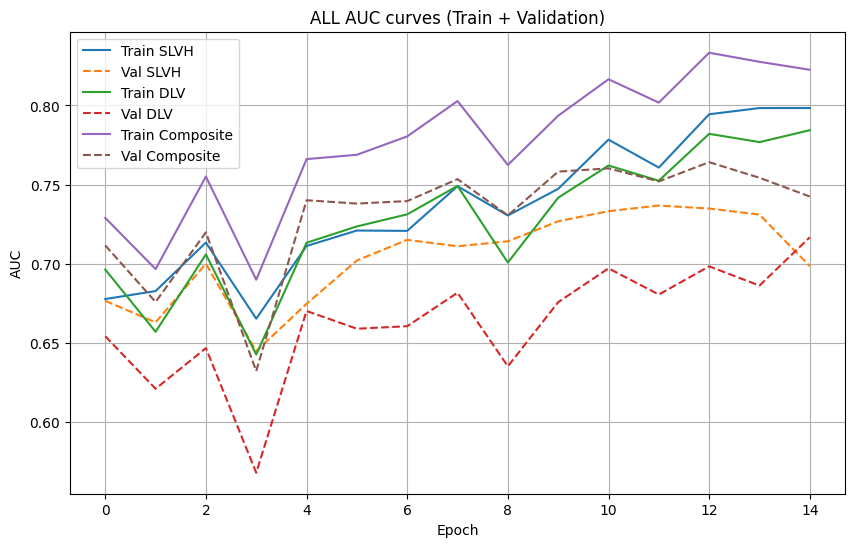

In [157]:
plt.figure(figsize=(10,6))

plt.plot(history["train_auc_slvh"], label="Train SLVH", linestyle="-")
plt.plot(history["val_auc_slvh"],   label="Val SLVH",   linestyle="--")

plt.plot(history["train_auc_dlv"],  label="Train DLV",  linestyle="-")
plt.plot(history["val_auc_dlv"],    label="Val DLV",    linestyle="--")

plt.plot(history["train_auc_comp"], label="Train Composite", linestyle="-")
plt.plot(history["val_auc_comp"],   label="Val Composite",   linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("ALL AUC curves (Train + Validation)")
plt.legend()
plt.grid(True)
plt.show()

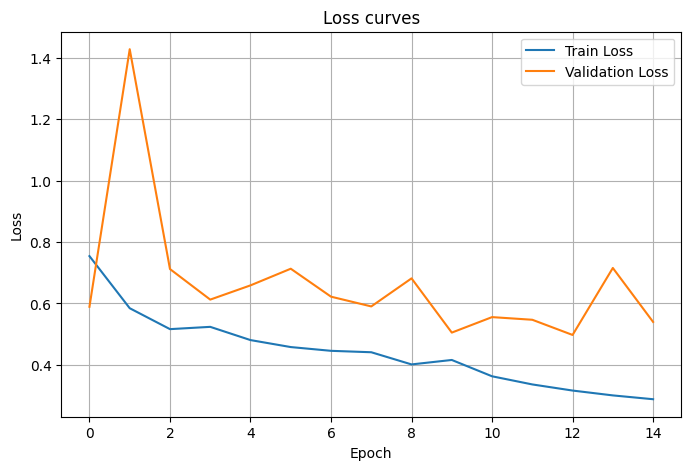

In [158]:
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"],   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.grid(True)
plt.show()

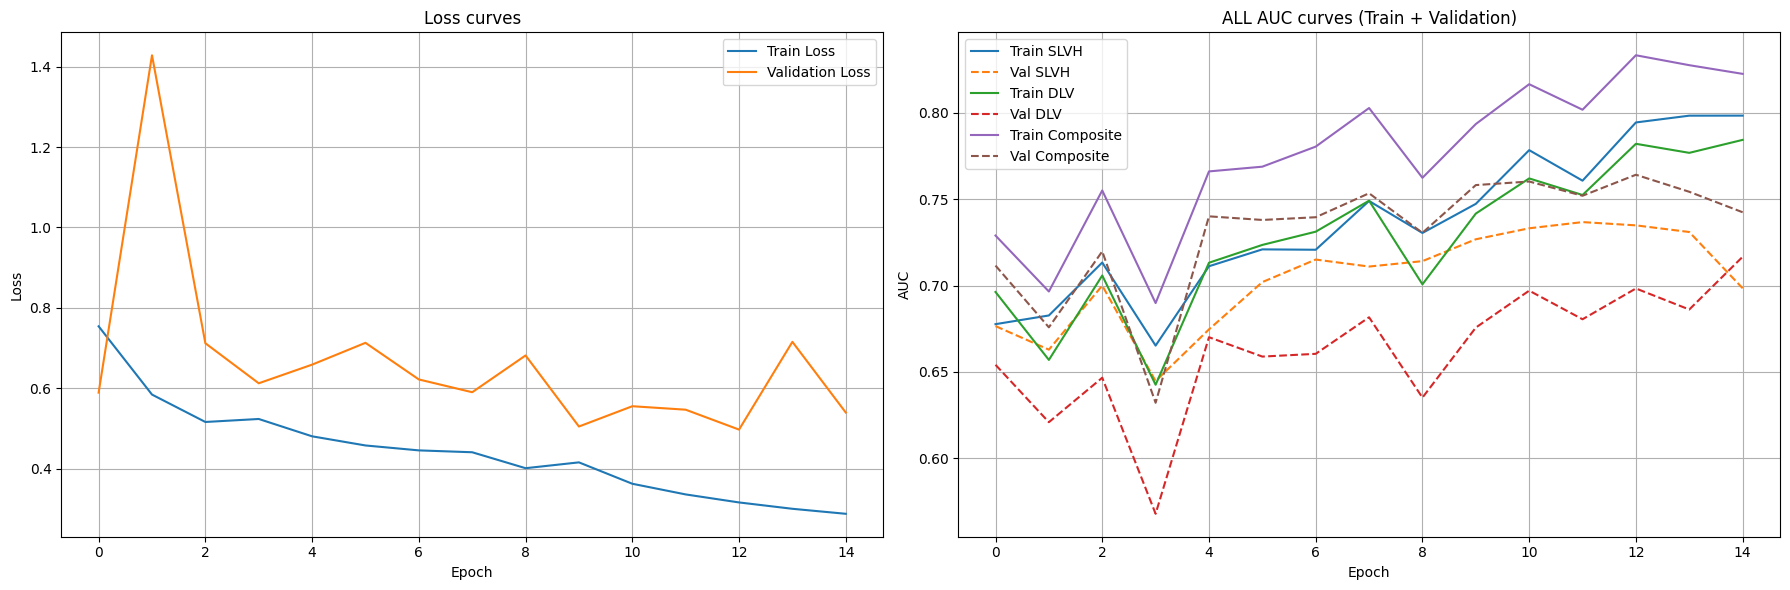

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Validation Loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history["train_auc_slvh"], label="Train SLVH", linestyle="-")
axes[1].plot(history["val_auc_slvh"],   label="Val SLVH",   linestyle="--")

axes[1].plot(history["train_auc_dlv"],  label="Train DLV",  linestyle="-")
axes[1].plot(history["val_auc_dlv"],    label="Val DLV",    linestyle="--")

axes[1].plot(history["train_auc_comp"], label="Train Composite", linestyle="-")
axes[1].plot(history["val_auc_comp"],   label="Val Composite",   linestyle="--")

axes[1].set_title("ALL AUC curves (Train + Validation)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


In [185]:
def find_threshold_at_sensitivity(y_true, y_prob, target_sens=0.66):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = (np.abs(tpr - target_sens)).argmin()
    return thresholds[idx]

def evaluate_test(model, loader, device, target_sensitivity=0.66):
    model.eval()
    all_probs = []
    all_targets = []
    all_losses = []

    with torch.no_grad():
        for img, age, sex_oh, reg_target, cls_target in loader:
            img        = img.to(device)
            age        = age.to(device)
            sex_oh     = sex_oh.to(device)
            reg_target = reg_target.to(device)
            cls_target = cls_target.to(device)

            mu, logvar = model(img, age, sex_oh)
            loss = gaussian_nll(mu, logvar, reg_target)
            all_losses.append(loss.item())

            probs = compute_probabilities(mu, logvar).cpu().numpy()
            targs = cls_target.cpu().numpy()

            all_probs.append(probs)
            all_targets.append(targs)

    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    auc_slvh = roc_auc_score(all_targets[:,0], all_probs[:,0])
    auc_dlv  = roc_auc_score(all_targets[:,1], all_probs[:,1])
    auc_comp = roc_auc_score(all_targets[:,2], all_probs[:,2])
    
    thr_slvh = find_threshold_at_sensitivity(all_targets[:,0], all_probs[:,0], target_sensitivity)
    thr_dlv  = find_threshold_at_sensitivity(all_targets[:,1], all_probs[:,1], target_sensitivity)
    thr_comp = find_threshold_at_sensitivity(all_targets[:,2], all_probs[:,2], target_sensitivity)

    thresholds = np.array([thr_slvh, thr_dlv, thr_comp])

    y_pred = (all_probs >= thresholds).astype(int)

    precision = precision_score(all_targets, y_pred, average=None)
    recall    = recall_score(all_targets, y_pred, average=None)
    f1        = f1_score(all_targets, y_pred, average=None)

    print(f"Test Loss           : {np.mean(all_losses):.4f}")

    print(f"Test AUC SLVH       : {auc_slvh:.4f}")
    print(f"Test AUC DLV        : {auc_dlv:.4f}")
    print(f"Test AUC Composite  : {auc_comp:.4f}\n")

    print("         Precision / Recall / F1")
    print(f"SLVH      P={precision[0]:.3f}  R={recall[0]:.3f}  F1={f1[0]:.3f}")
    print(f"DLV       P={precision[1]:.3f}  R={recall[1]:.3f}  F1={f1[1]:.3f}")
    print(f"Composite P={precision[2]:.3f}  R={recall[2]:.3f}  F1={f1[2]:.3f}")

    return {
        "loss": np.mean(all_losses),
        "auc": (auc_slvh, auc_dlv, auc_comp),
        "thresholds": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": all_targets,
        "y_prob": all_probs,
        "y_pred": y_pred
    }

In [186]:
model = GaussianLVModel().to(device)
model.load_state_dict(torch.load("best_gaussian_model.pth", map_location=device))

results = evaluate_test(model, test_loader, device, target_sensitivity=0.70)

Test Loss           : 0.4195
Test AUC SLVH       : 0.7208
Test AUC DLV        : 0.7484
Test AUC Composite  : 0.7869

         Precision / Recall / F1
SLVH      P=0.420  R=0.698  F1=0.524
DLV       P=0.446  R=0.712  F1=0.548
Composite P=0.718  R=0.701  F1=0.710
